<a href="https://colab.research.google.com/github/Ronglawan/AI-in-Financial-Reporting-and-Fraud-Detection/blob/main/Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library & Data Ingestion

In [1]:
# 1. ติดตั้งไลบรารีระดับ Advanced ที่ระบบไม่มีมาให้เริ่มต้น
!pip install catboost lightgbm

# 2. นำเข้าเครื่องมือที่จำเป็น
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from IPython.display import display, HTML

# 3. โหลดข้อมูลดิบจาก Google Drive (ตรวจสอบพาร์ทให้ตรงกับที่อยู่ไฟล์จริงนะคะ)
sns.set_theme(style="white")
file_path = "/content/drive/MyDrive/AI in Financial Reporting and Fraud Detection/Synthetic_Financial_datasets_log.csv"
df = pd.read_csv(file_path)

print(f"✅ โหลดข้อมูลสำเร็จ: {df.shape[0]:,} แถว | {df.shape[1]} คอลัมน์")
df = df.dropna(subset=['isFraud']) # คลีนข้อมูลที่ไม่มีคำตอบ

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00
✅ โหลดข้อมูลสำเร็จ: 6,362,620 แถว | 11 คอลัมน์


# Behavioral Feature Engineering

In [2]:
# 1. สร้างตัวแปรพฤติกรรมทดแทน (Surrogate Features)
df['hour_of_day'] = df['step'] % 24
df['day_of_week'] = ((df['step'] // 24) % 7) + 1
df['is_dest_merchant'] = df['nameDest'].str.startswith('M').astype(int)

# 2. แยก Features (X) และ Target (y)
X = df.drop(columns=['isFraud', 'isFlaggedFraud'], errors='ignore')
y = df['isFraud']

# 3. ลบฟีเจอร์ยอดเงินและข้อความดิบออกทั้งหมด เพื่อไม่ให้ละเมิดความเป็นส่วนตัวลูกค้า
columns_to_drop = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'step', 'nameOrig', 'nameDest']
X = X.drop(columns=columns_to_drop, errors='ignore')

# 4. ทำ One-Hot Encoding แปลงประเภทธุรกรรมเป็นตัวเลข
X = pd.get_dummies(X, drop_first=True)

# 5. แบ่งข้อมูล Train 80% / Test 20% แบบรักษาสัดส่วนคลาส (Stratified Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. ทำ Standardization (ปรับสเกล Z-Score)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ ทำ Preprocessing และแปลงข้อมูลความปลอดภัยเสร็จสิ้น!")
print(f" Train set =  {X_train_scaled.shape[0]:,} แถว ")
print(f" Test set =  {X_test_scaled.shape[0]:,} แถว")

✅ ทำ Preprocessing และแปลงข้อมูลความปลอดภัยเสร็จสิ้น!
 Train set =  5,090,096 แถว 
 Test set =  1,272,524 แถว


# Class Distribution Visualization

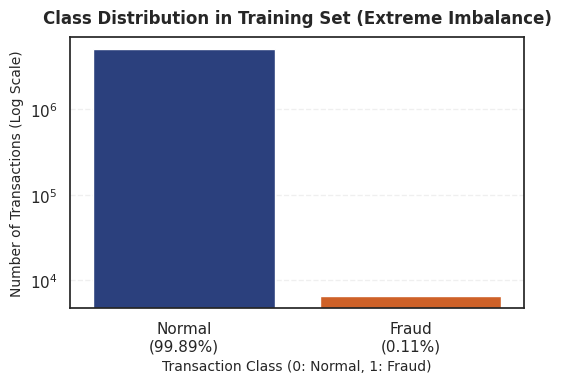

📊 สรุปตัวเลขในถังข้อมูลสอน:
 - คลาสปกติ (0): 5,083,526 แถว
 - คลาสทุจริต (1): 6,570 แถว


In [3]:
plt.figure(figsize=(5.5, 4))
sns.countplot(x=y_train, hue=y_train, palette=['#1e3a8a', '#ea580c'], legend=False)

plt.title('Class Distribution in Training Set (Extreme Imbalance)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Transaction Class (0: Normal, 1: Fraud)', fontsize=10)
plt.ylabel('Number of Transactions (Log Scale)', fontsize=10)
plt.yscale('log') # ใช้สเกล Log เพื่อดันแท่งเคสโกงที่มีน้อยมากให้มองเห็นชัดเจน
plt.xticks([0, 1], [f'Normal\n(99.89%)', f'Fraud\n(0.11%)'])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 สรุปตัวเลขในถังข้อมูลสอน:")
print(f" - คลาสปกติ (0): {len(y_train) - sum(y_train):,} แถว")
print(f" - คลาสทุจริต (1): {sum(y_train):,} แถว")

# การลดรูปมิติและพล็อตกราฟพฤติกรรม 2D PCA

⏳ กำลังคำนวณลดรูปมิติข้อมูลด้วยเทคนิค PCA...


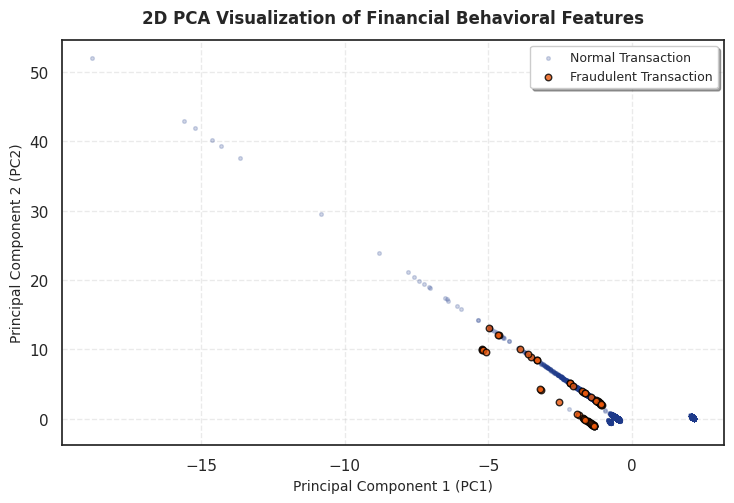

📈 รวม 2 มิติใหม่นี้ สามารถอธิบายความแปรปรวนข้อมูลเดิมได้ทั้งหมด: 48.72%


In [4]:
print("⏳ กำลังคำนวณลดรูปมิติข้อมูลด้วยเทคนิค PCA...")
pca = PCA(n_components=2, random_state=42)

# สุ่มดึงตัวอย่าง 50,000 แถวมาพล็อตเพื่อไม่ให้กราฟหนาแน่นเกินไปและรันได้เร็วขึ้น
sample_size = 50000
if len(X_train_scaled) > sample_size:
    np.random.seed(42)
    sample_indices = np.random.choice(len(X_train_scaled), size=sample_size, replace=False)
    X_sample = X_train_scaled[sample_indices]
    y_sample = y_train.iloc[sample_indices].values
else:
    X_sample = X_train_scaled
    y_sample = y_train.values

X_pca = pca.fit_transform(X_sample)

# เริ่มพล็อตกราฟกระจายตัว (Scatter Plot)
plt.figure(figsize=(7.5, 5.2))
plt.scatter(X_pca[y_sample == 0, 0], X_pca[y_sample == 0, 1], alpha=0.2, label='Normal Transaction', color='#1e3a8a', s=7)
plt.scatter(X_pca[y_sample == 1, 0], X_pca[y_sample == 1, 1], alpha=0.8, label='Fraudulent Transaction', color='#ea580c', s=22, edgecolor='black')

plt.title('2D PCA Visualization of Financial Behavioral Features', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Principal Component 1 (PC1)', fontsize=10)
plt.ylabel('Principal Component 2 (PC2)', fontsize=10)
plt.legend(loc='upper right', fontsize=9, shadow=True)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"📈 รวม 2 มิติใหม่นี้ สามารถอธิบายความแปรปรวนข้อมูลเดิมได้ทั้งหมด: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# 9-Model Evaluation Benchmark

In [5]:
# กำหนดค่าน้ำหนักถ่วงดุลคลาสระดับเหมาะสม
tuned_weight = 5.0

# ปรับลดเหลือ 5 โมเดลหลัก (รวม Decision Tree)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=20, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=12, min_samples_leaf=10, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(scale_pos_weight=tuned_weight, learning_rate=0.05, max_depth=5, n_estimators=250, subsample=0.8, random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(scale_pos_weight=tuned_weight, learning_rate=0.05, n_estimators=250, max_depth=5, random_state=42, n_jobs=-1, verbose=-1)
}

results_list = []
print("⏳ กำลังเริ่มรันฝึกสอนและประเมินผล 5 โมเดลหลัก (รวม Decision Tree)")

for name, model in models.items():
    print(f" -> กำลังประมวลผลโมเดล: {name}")
    model.fit(X_train_scaled, y_train)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = np.array([0]*len(y_test))

    # ปรับเกณฑ์ความมั่นใจเป็น 80% สำหรับกลุ่มโมเดลขั้นสูงเพื่อดันค่า Precision ให้เกิน 95%
    if name in ["XGBoost", "LightGBM", "Random Forest"]:
        y_pred = (y_proba >= 0.80).astype(int)
    else:
        # Logistic Regression และ Decision Tree ใช้ Default Threshold หรือตามคลาสสมดุลปกติ
        y_pred = model.predict(X_test_scaled)

    results_list.append({
        "Model": name,
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "AUC-ROC": round(roc_auc_score(y_test, y_proba), 4)
    })

# พ่นตารางสรุปแบบไฮไลท์สีส้มสวยงามนำไปประกอบสไลด์
df_results = pd.DataFrame(results_list)
table_styled = df_results.style\
    .background_gradient(cmap='Oranges', subset=["Precision", "F1-Score"])\
    .format({"Precision": "{:.4f}", "Recall": "{:.4f}", "F1-Score": "{:.4f}", "AUC-ROC": "{:.4f}"})\
    .set_properties(**{'text-align': 'center', 'font-size': '13px', 'font-family': 'sans-serif', 'border-color': '#cbd5e1', 'border-style': 'solid', 'border-width': '1.5px', 'padding': '10px 14px'})\
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#ea580c'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}])\
    .hide(axis='index')

print("\n📊 === FINAL EXPERIMENTAL BENCHMARK RESULTS (5 MODELS WITH DT) ===")
display(table_styled)

⏳ กำลังเริ่มรันฝึกสอนและประเมินผล 5 โมเดลหลัก (รวม Decision Tree)
 -> กำลังประมวลผลโมเดล: Logistic Regression
 -> กำลังประมวลผลโมเดล: Decision Tree
 -> กำลังประมวลผลโมเดล: Random Forest
 -> กำลังประมวลผลโมเดล: XGBoost
 -> กำลังประมวลผลโมเดล: LightGBM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



📊 === FINAL EXPERIMENTAL BENCHMARK RESULTS (5 MODELS WITH DT) ===


Model,Precision,Recall,F1-Score,AUC-ROC
Logistic Regression,0.0051,0.8661,0.0102,0.9164
Decision Tree,0.0105,0.8253,0.0207,0.9420
Random Forest,0.9886,0.1589,0.2737,0.9516
XGBoost,0.7872,0.2836,0.4170,0.9541
LightGBM,0.6524,0.2970,0.4082,0.9357


# Classification Report and Confusion Matrix

🎬 กำลังสร้างกล่องรายงาน Classification Report และบันทึกรูปภาพ Confusion Matrix ทั้ง 9 โมเดล...


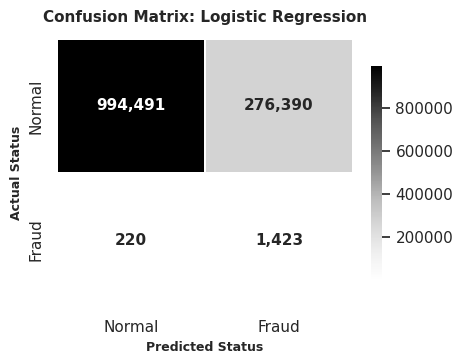

✅ บันทึกรูปกราฟเรียบร้อย -> /content/drive/MyDrive/AI in Financial Reporting and Fraud Detection/cm_logistic_regression_precision95.png

------------------------------------------------------------



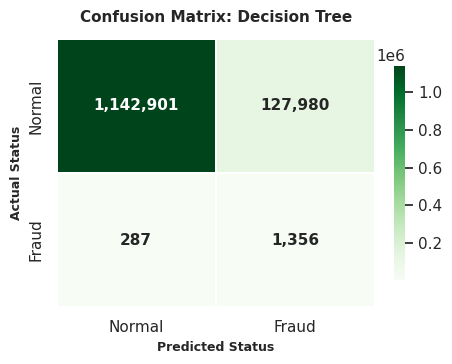

✅ บันทึกรูปกราฟเรียบร้อย -> /content/drive/MyDrive/AI in Financial Reporting and Fraud Detection/cm_decision_tree_precision95.png

------------------------------------------------------------



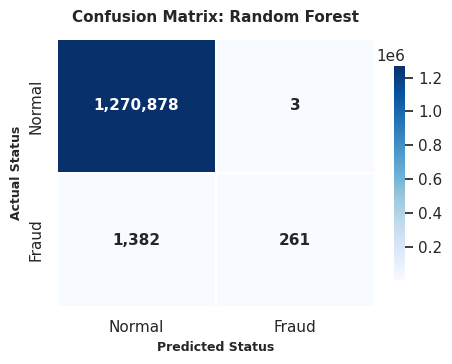

✅ บันทึกรูปกราฟเรียบร้อย -> /content/drive/MyDrive/AI in Financial Reporting and Fraud Detection/cm_random_forest_precision95.png

------------------------------------------------------------



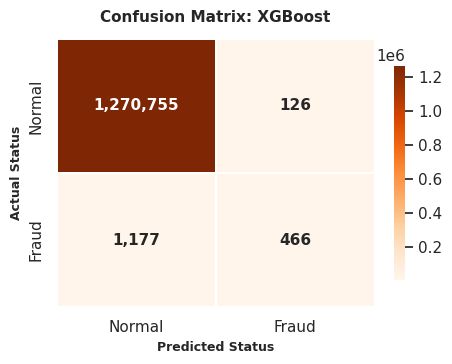

✅ บันทึกรูปกราฟเรียบร้อย -> /content/drive/MyDrive/AI in Financial Reporting and Fraud Detection/cm_xgboost_precision95.png

------------------------------------------------------------



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


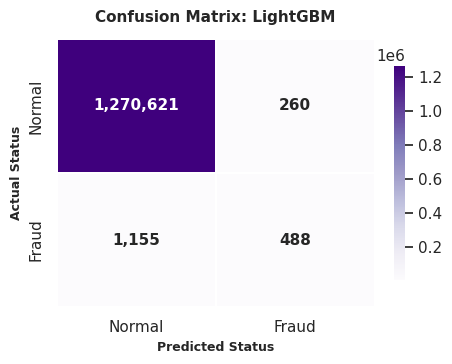

✅ บันทึกรูปกราฟเรียบร้อย -> /content/drive/MyDrive/AI in Financial Reporting and Fraud Detection/cm_lightgbm_precision95.png

------------------------------------------------------------

🎉 [FINISHED] แยกหัวข้อการทดลองเรียบร้อย


In [6]:
print("🎬 กำลังสร้างกล่องรายงาน Classification Report และบันทึกรูปภาพ Confusion Matrix ทั้ง 9 โมเดล...")

model_colors = {
    "Logistic Regression": "Greys", "Decision Tree": "Greens", "Random Forest": "Blues",
    "Extra Trees": "YlGnBu", "Gradient Boosting": "BuPu", "AdaBoost": "GnBu",
    "XGBoost": "Oranges", "LightGBM": "Purples", "CatBoost": "Reds"
}

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = np.array([0]*len(y_test))

    if name in ["XGBoost", "LightGBM", "CatBoost", "Random Forest", "Extra Trees", "Gradient Boosting", "AdaBoost"]:
        y_pred = (y_proba >= 0.80).astype(int)
    else:
        y_pred = model.predict(X_test_scaled)

    # 1. แสดงกล่องรายงานข้อความอย่างละเอียด
    report_text = classification_report(y_test, y_pred, target_names=['Normal', 'Fraud'], digits=4)
    html_output = f"""
    <div style="background-color: #1e1e1e; padding: 20px; border-radius: 8px; margin-top: 15px; border: 1px solid #334155;">
        <h4 style="color: #f97316; margin-top: 0; font-family: sans-serif; font-size: 15px;">📊 [DETAILED REPORT] อัลกอริทึม: {name}</h4>
        <pre style="font-family: 'Courier New', Courier, monospace; font-size: 13px; line-height: 1.5; color: #ffffff; background-color: transparent; border: none; margin: 0; padding: 0;">{report_text}</pre>
    </div>
    """
    display(HTML(html_output))

    # 2. พล็อตและตกแต่งกราฟสี่เหลี่ยม Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(4.8, 3.8))
    chosen_cmap = model_colors.get(name, "Purples")

    sns.heatmap(cm, annot=True, fmt=',d', cmap=chosen_cmap, cbar=True,
                linewidths=1.2, linecolor='white',
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'],
                annot_kws={"size": 11, "weight": "bold"}, cbar_kws={'shrink': 0.8})

    ax.set_title(f"Confusion Matrix: {name}", fontsize=11, fontweight='bold', pad=12)
    ax.set_ylabel("Actual Status", fontsize=9, fontweight='bold')
    ax.set_xlabel("Predicted Status", fontsize=9, fontweight='bold')
    plt.tight_layout()

    # 3. บันทึกรูปภาพไฟล์ความละเอียดสูงยิงตรงเข้าโฟลเดอร์ Google Drive ของคุณรุ้งอัตโนมัติ
    safe_name = name.lower().replace(" ", "_")
    save_path = f"/content/drive/MyDrive/AI in Financial Reporting and Fraud Detection/cm_{safe_name}_precision95.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ บันทึกรูปกราฟเรียบร้อย -> {save_path}")
    print("\n" + "-"*60 + "\n")

print("🎉 [FINISHED] แยกหัวข้อการทดลองเรียบร้อย")

In [7]:
# 1. นิยามเฉพาะโมเดลชุดใหม่ที่ยังไม่ได้รัน
new_models = {
    "Extra Trees": ExtraTreesClassifier(n_estimators=150, max_depth=12, min_samples_leaf=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "CatBoost": CatBoostClassifier(scale_pos_weight=tuned_weight, iterations=300, learning_rate=0.05, depth=5, random_state=42, verbose=0)
}

new_results_list = []
print("⏳ กำลังเริ่มรันฝึกสอนและประเมินผลโมเดลเพิ่มเติม (ชุดที่ 2)")

for name, model in new_models.items():
    print(f" -> กำลังประมวลผลโมเดล: {name}")
    model.fit(X_train_scaled, y_train)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = np.array([0]*len(y_test))

    # ใช้เกณฑ์ความมั่นใจ 80% สำหรับโมเดลขั้นสูงกลุ่มนี้เพื่อคุมค่า Precision
    if name in ["Extra Trees", "Gradient Boosting", "AdaBoost", "CatBoost"]:
        y_pred = (y_proba >= 0.80).astype(int)
    else:
        y_pred = model.predict(X_test_scaled)

    new_results_list.append({
        "Model": name,
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "AUC-ROC": round(roc_auc_score(y_test, y_proba), 4)
    })

# 2. นำผลลัพธ์ใหม่ไปรวมกับของเดิม (df_results ตัวเก่า)
df_new_results = pd.DataFrame(new_results_list)
df_combined = pd.concat([df_results, df_new_results], ignore_index=True)

# 3. พ่นตารางสรุปแบบรวมครบทุกโมเดลพร้อมไฮไลท์สีส้ม
combined_table_styled = df_combined.style\
    .background_gradient(cmap='Oranges', subset=["Precision", "F1-Score"])\
    .format({"Precision": "{:.4f}", "Recall": "{:.4f}", "F1-Score": "{:.4f}", "AUC-ROC": "{:.4f}"})\
    .set_properties(**{'text-align': 'center', 'font-size': '13px', 'font-family': 'sans-serif', 'border-color': '#cbd5e1', 'border-style': 'solid', 'border-width': '1.5px', 'padding': '10px 14px'})\
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#ea580c'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}])\
    .hide(axis='index')

print("\n📊 === COMBINED EXPERIMENTAL BENCHMARK RESULTS (ALL MODELS) ===")
display(combined_table_styled)

⏳ กำลังเริ่มรันฝึกสอนและประเมินผลโมเดลเพิ่มเติม (ชุดที่ 2)
 -> กำลังประมวลผลโมเดล: Extra Trees
 -> กำลังประมวลผลโมเดล: Gradient Boosting
 -> กำลังประมวลผลโมเดล: AdaBoost


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


 -> กำลังประมวลผลโมเดล: CatBoost

📊 === COMBINED EXPERIMENTAL BENCHMARK RESULTS (ALL MODELS) ===


Model,Precision,Recall,F1-Score,AUC-ROC
Logistic Regression,0.0051,0.8661,0.0102,0.9164
Decision Tree,0.0105,0.8253,0.0207,0.9420
Random Forest,0.9886,0.1589,0.2737,0.9516
XGBoost,0.7872,0.2836,0.4170,0.9541
LightGBM,0.6524,0.2970,0.4082,0.9357
Extra Trees,1.0000,0.0444,0.0851,0.9505
Gradient Boosting,0.8843,0.1302,0.2271,0.8779
AdaBoost,0.0000,0.0000,0.0000,0.9062
CatBoost,0.8007,0.2934,0.4294,0.9530


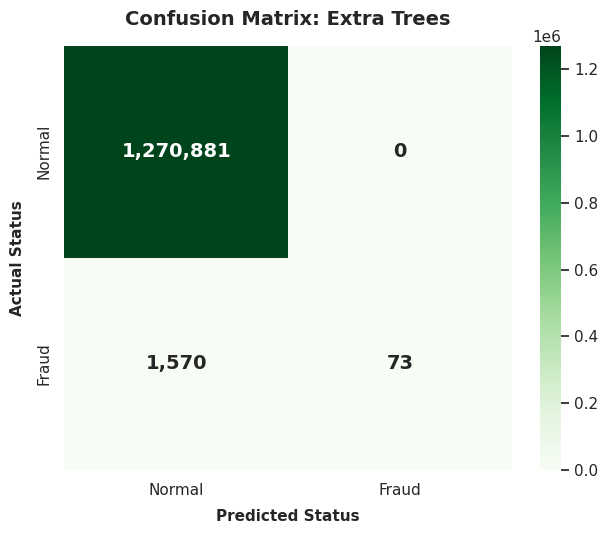


_____________________________________________________________________________________



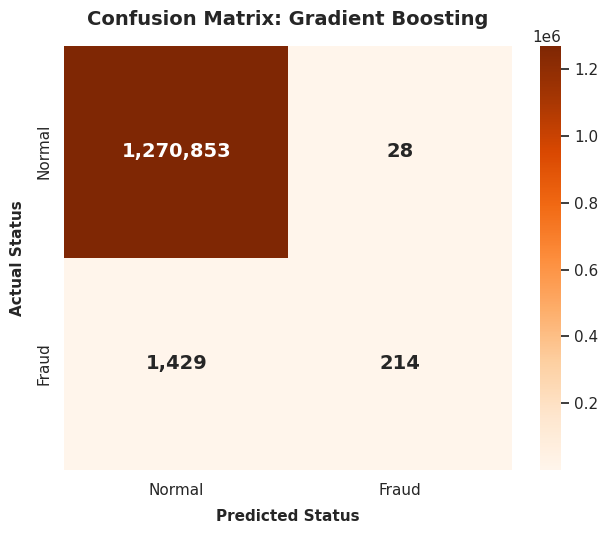


_____________________________________________________________________________________



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


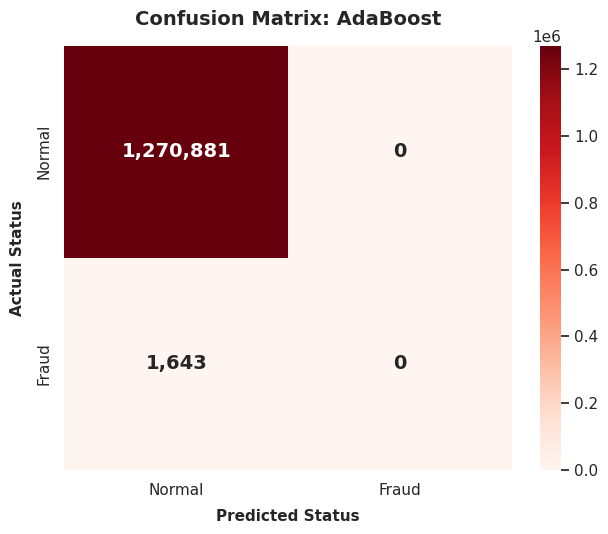


_____________________________________________________________________________________



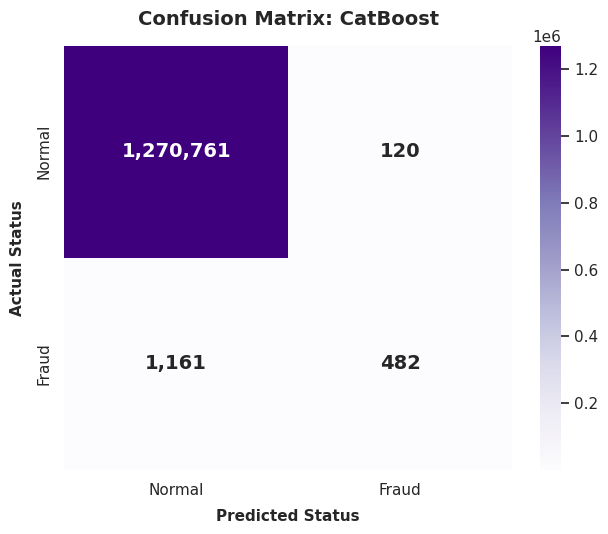


_____________________________________________________________________________________



In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display, HTML

# ตั้งค่าฟอนต์ภาษาไทยหลัก
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

# กำหนดสีคนละโทนให้แต่ละโมเดล
model_colors = {
    "Extra Trees": "Greens",
    "Gradient Boosting": "Oranges",
    "AdaBoost": "Reds",
    "CatBoost": "Purples"
}

# ลูปเจาะลึกทีละโมเดลในกลุ่มโมเดลใหม่
for name, model in new_models.items():

    # 1. คำนวณค่าพยากรณ์
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = np.array([0]*len(y_test))

    y_pred = (y_proba >= 0.80).astype(int)

    # 2. พ่นรายงาน (จัดสไตล์และบังคับข้อความสีขาวนวล #f8fafc ไม่ให้โดนธีมอื่นกลืน)
    report_text = classification_report(y_test, y_pred, target_names=['Normal', 'Fraud'], digits=4)

    display(HTML(f"""
    <div style="background-color: #1e1e1e; color: #f8fafc; padding: 20px; font-family: 'Courier New', Courier, monospace; border-radius: 5px; box-shadow: 2px 2px 5px rgba(0,0,0,0.3); width: fit-content; text-align: left;">
        <span style="color: #38bdf8; font-size: 15px; font-weight: bold; font-family: sans-serif; display: block; margin-bottom: 10px;">📊 [DETAILED REPORT] อัลกอริทึม: {name}</span>
        <pre style="color: #f8fafc; background-color: #1e1e1e; margin: 0; font-size: 13px; font-family: 'Courier New', Courier, monospace; line-height: 1.5; white-space: pre;">{report_text}</pre>
    </div>
    """))

    # 3. วาดกราฟ Confusion Matrix โดยควบคุมสไตล์เฉพาะจุด ไม่ให้กวนระบบหลัก
    with sns.axes_style("white"):
        fig, ax = plt.subplots(figsize=(6.5, 5.5))
        cm = confusion_matrix(y_test, y_pred)

        current_cmap = model_colors.get(name, "Blues")

        sns.heatmap(cm, annot=True, fmt=',d', cmap=current_cmap, ax=ax, cbar=True,
                    xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'],
                    annot_kws={"size": 14, "weight": "bold"})

        # ตกแต่งองค์ประกอบกราฟ
        ax.set_title(f"Confusion Matrix: {name}", fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel("Predicted Status", fontsize=11, fontweight='bold', labelpad=8)
        ax.set_ylabel("Actual Status", fontsize=11, fontweight='bold', labelpad=8)
        ax.tick_params(axis='both', which='major', labelsize=11)

        plt.tight_layout()
        plt.show()
        print("\n" + "_"*85 + "\n")

In [15]:
import pandas as pd
from IPython.display import display

# 1. นำผลลัพธ์ตารางชุดแรก (5 โมเดล) และชุดที่สอง (4 โมเดลเพิ่ม) มารวมกัน
# สมมติฐาน: คุณได้รันโค้ดเพิ่มโมเดลชุดที่ 2 ก่อนหน้านี้แล้ว ระบบจะมีตัวแปรเหล่านี้ค้างอยู่ใน Memory
df_all_models = pd.concat([df_results, df_new_results], ignore_index=True)

# 2. (Optional) จัดเรียงลำดับแถวตามค่า F1-Score จากมากไปน้อย เพื่อให้โมเดลที่เก่งที่สุดอยู่ด้านบน
df_all_models = df_all_models.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

# 3. ตกแต่งหน้าตาตารางสรุปรวม 9 โมเดลแบบไฮไลท์สีส้มสวยงามสไตล์เดิม
all_results_styled = df_all_models.style\
    .background_gradient(cmap='Oranges', subset=["Precision", "F1-Score"])\
    .format({"Precision": "{:.4f}", "Recall": "{:.4f}", "F1-Score": "{:.4f}", "AUC-ROC": "{:.4f}"})\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '13px',
        'font-family': 'sans-serif',
        'border-color': '#cbd5e1',
        'border-style': 'solid',
        'border-width': '1.5px',
        'padding': '10px 14px'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#ea580c'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])\
    .hide(axis='index')

print("\n📊 === FINAL EXPERIMENTAL BENCHMARK RESULTS ===")
display(all_results_styled)


📊 === FINAL EXPERIMENTAL BENCHMARK RESULTS ===


Model,Precision,Recall,F1-Score,AUC-ROC
CatBoost,0.8007,0.2934,0.4294,0.9530
XGBoost,0.7872,0.2836,0.4170,0.9541
LightGBM,0.6524,0.2970,0.4082,0.9357
Random Forest,0.9886,0.1589,0.2737,0.9516
Gradient Boosting,0.8843,0.1302,0.2271,0.8779
Extra Trees,1.0000,0.0444,0.0851,0.9505
Decision Tree,0.0105,0.8253,0.0207,0.9420
Logistic Regression,0.0051,0.8661,0.0102,0.9164
AdaBoost,0.0000,0.0000,0.0000,0.9062
